# Phase 2a-2. DEG analysis & paper marker overlap validation

이 notbook의 목적은 TAM subtype annoation 이후 각 subtype을 특징짓는 DEG(Differentially Expressed Genes)를 찾고 논문에서 제시한 maker gene과 overlap되는지 검증하는 것이다.

핵심 질문:
- C1QC+ TAM과 SPP1+ TAM은 실제로 서로 다른 transcriptional signiture를 가지는가?
- 논문 marker gene이 GSE127465 폐암 데이터에서도 DEG 상위권에 재현되는가?

## 0. 왜 annoation 이후 DEG 분석을 다시 하는가?

Annoation은 marker gene 기반으로 cluster에 이름을 붙이는 interpretation 단계다.

반면 DEG 분석은 각 cluster/subtype을 특징짓는 gene이 실제 데이터에서 통계적으로 유의미하게 높게 발현되는지 확인하는 단계이다.

즉:
- annotation: known marker를 보고 이름을 붙임
- DEG: 이 그룹을 가장 잘 설명하는 gene signature를 데이터에서 다시 찾음

따라서 DEG는 annotation의 근거를 강화하고 논문 marker와의 재현성을 검증하는 역할을 한다.

In [1]:

import scanpy as sc
import pandas as pd
import numpy as np
import sys
from pathlib import Path
sys.path.insert(0, str(Path('..').resolve()))
from utils.paths import *

mac = sc.read_h5ad(MAC_SUB_H5AD)

print(mac)
print(mac.obs['tam_subtype'].value_counts())
print('raw exists:', mac.raw is not None)
print('raw shape:', None if mac.raw is None else mac.raw.shape)

AnnData object with n_obs × n_vars = 9567 × 32634
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'outlier', 'mt_outlier', 'n_counts', 'sample', 'leiden', 'cell_type', 'leiden_7', 'leiden_8', 'leiden_9', 'leiden_10', 'leiden_12', 'leiden_15', 'leiden_r0.1', 'leiden_r0.2', 'leiden_r0.3', 'leiden_r0.4', 'leiden_r0.5', 'leiden_r0.6', 'leiden_r0.7', 'leiden_r0.8', 'leiden_r0.9', 'leiden_r1.0', 'C1QC_score', 'SPP1_score', 'Resting_C1QC_score', 'Activated_C1QC_score', 'ISG15_score', 'tam_subtype'
    var: 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'n_cells', 'dispersions', 'dispersio

## 1. DEG 분석 설계

Macrophage subset의 DEG 분석은 하나의 질문으로 처리하지 않고, 목적이 다른 두 단계로 구분하여 수행한다.

### DEG-A. Subtype marker gene identification

각 tam_subtype이 나머지 macrophage population과 비교했을때 상대적으로 높게 발현하는 gene을 확인한다.  

- C1QC+ TAM vs rest
- SPP1+ TAM vs rest
- C1QC+ TAM(tentative) vs rest
- SPP1+ TAM(tentative) vs rest

이 분석의 목적은 각 subtype의 전사적 특징을 확인하고 기존 marker score 기반 annotation이 DEG 수준에서도 지지되는지 검증하는 것이다.  

특히 C1QC+ TAM에서는 complement / lipid-associated macrophage관련 gene이, SPP1+ TAM에서는 논문 Table S3에서 제시된 SPP1-associated gene이 상대적으로 높게 나타나는지 확인한다.  

In [2]:
print("mac shape      :", mac.shape)
print("mac.raw exists :", mac.raw is not None)

if mac.raw is not None:
    print("mac.raw shape  :", mac.raw.shape)
    print("X genes        :", mac.n_vars)
    print("raw genes      :", mac.raw.n_vars)

print("\nX min / max:")
print(mac.X.min(), mac.X.max())

if mac.raw is not None:
    print("\nraw min / max:")
    print(mac.raw.X.min(), mac.raw.X.max())

mac shape      : (9567, 32634)
mac.raw exists : False

X min / max:
0.0 8.185986


현재 상태는 mac.X가 scale된 값이 아니라 log-normalized expression matrix이고 이전에 filter_genes(min_cells=3)를 거친 뒤 남은 32,634개의 gene이 들어있음
use_raw=True를 할필요가 없다.
.X의 32634개의 gene은 macrophage subset안에서 최소 3개 이상 세포에 발현된 유전자들이라서 DEG 대상이 된다.  
filter_genes(min_cells=3)로 제거 된 약 9000개의 유전자는 이 subset에서 사실 거의 안나오기 떄문에 marker/DEG 해석에서 잃는 정보는 거의 적다.  

`use_raw=False`를 사용하는 이유:  
- macrophage subset 재구축 과정에서 `mac.X`는 QC -> normalize_total -> log1p 이후의 log-normalized expression matrix로 유지하였다.
- HVG는 PCA 및 Harmony 계산을 위한 feature selection에만 사용했으며, `mac.X` 자체를 HVG 2,000개로 subset하지 않았다.
- DEG는 Harmony/PCA 좌표가 아닌, macrophage subset에서 최소 3개 이상의 세포에 발현된 전체 32,634개 gene의 log-normalized expression matrix를 기준으로 수행한다.
- `.raw`는 설정하지 않았으므로 `use_raw=False`를 사용한다.

dict_keys(['params', 'pts', 'pts_rest', 'names', 'scores', 'pvals', 'pvals_adj', 'logfoldchanges'])


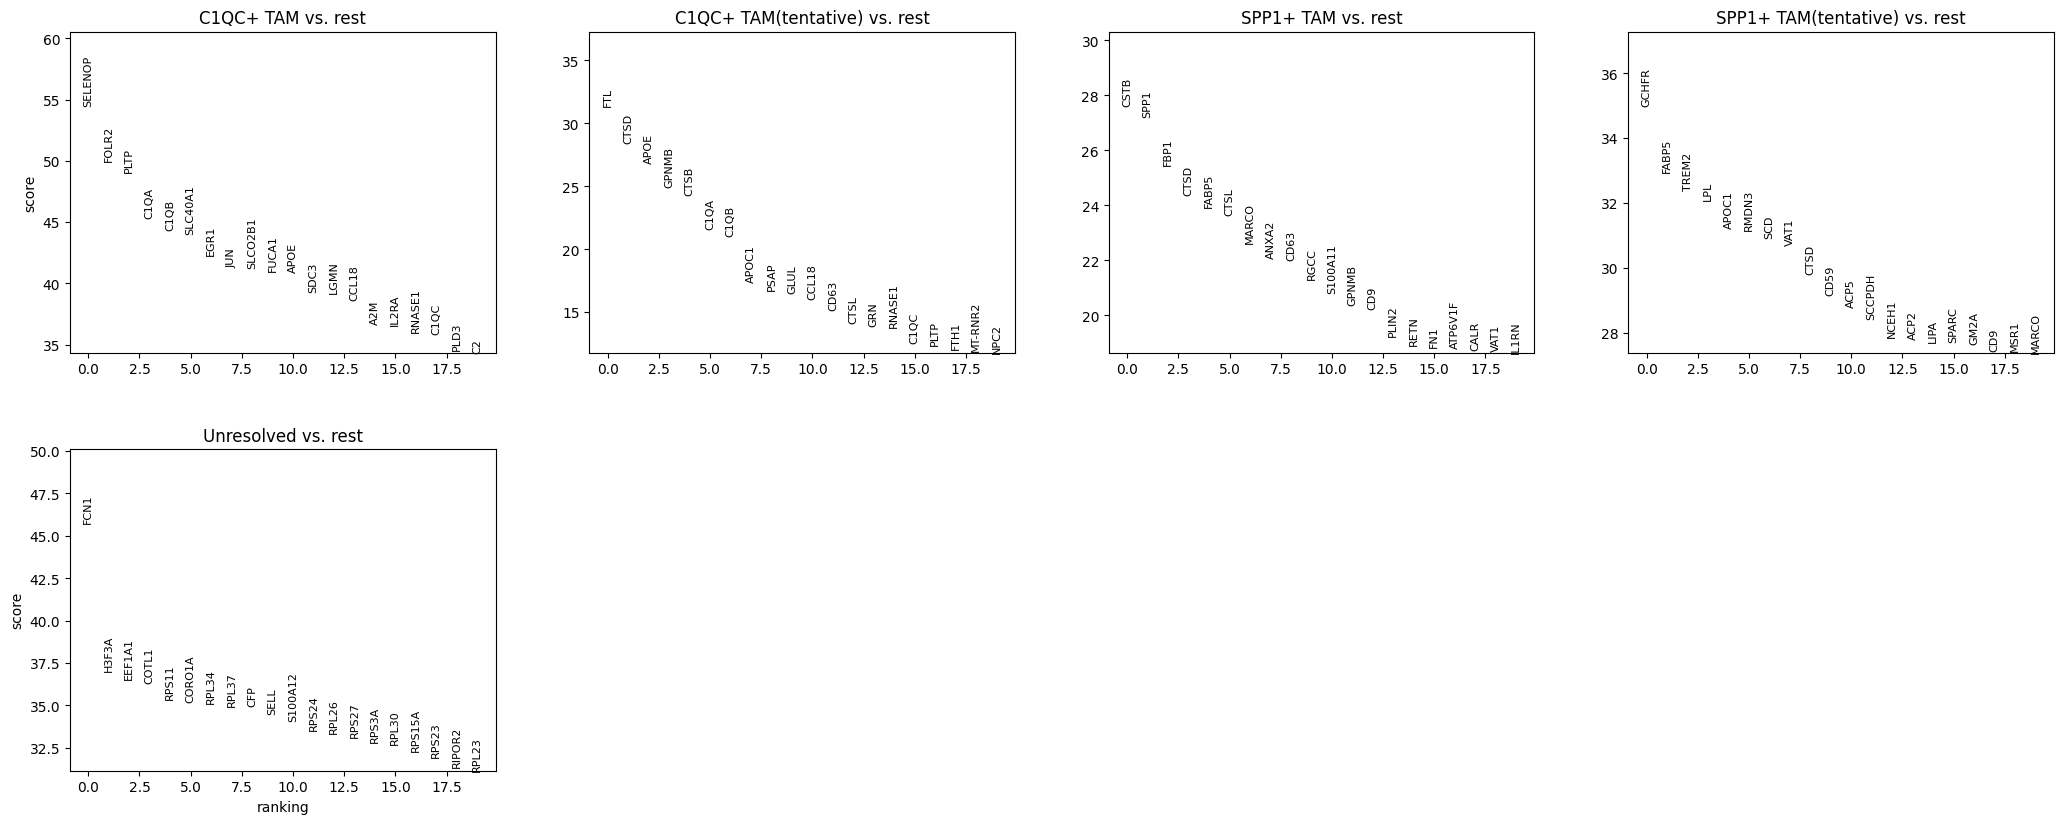

In [9]:
DEG_KEY_A = "deg_subtype_vs_rest"

sc.tl.rank_genes_groups(
    mac,
    groupby="tam_subtype",
    groups="all",
    reference="rest",
    method="wilcoxon",
    corr_method="bonferroni",
    tie_correct=True,
    use_raw=False,
    pts=True,
    key_added=DEG_KEY_A,
)

print(mac.uns[DEG_KEY_A].keys())

sc.pl.rank_genes_groups(
    mac,
    key=DEG_KEY_A,
    n_genes=20,
    sharey=False,
)

## 2. DEG 결과 table로 확인

plot만으로는 개별 유전자의 발현 차이와 통계적 유의성을 정량적으로 확인하기 어렵기 때문에 각 subtype의 DEG 결과를 dataframe으로 추출하였다.

주요 확인 항목:
- names: DEG gene name
- logfoldchanges: 다른 subtype 대비 발현 증가 정도 (log2 fold change)
- pvals_adj: multiple testing correction 이후의 adjusted p-value
- scores: Wilcoxon rank-sum test statistic

이후 논문 Supplementary Table S3의 DEG signature와 비교하기 위해 상위 DEG를 추출하여 사용하였다.

In [12]:
sc.tl.rank_genes_groups(
    mac,
    groupby="tam_subtype",
    groups="all",
    reference="rest",
    method="wilcoxon",
    corr_method="bonferroni",
    tie_correct=True,
    use_raw=False,
    pts=True,
    key_added=DEG_KEY_A,
)
deg_tables = {}

for group in (
    mac.obs["tam_subtype"].cat.categories
    if hasattr(mac.obs["tam_subtype"], "cat")
    else sorted(mac.obs["tam_subtype"].unique())
):
    df = sc.get.rank_genes_groups_df(
        mac,
        group=group,
        key=DEG_KEY_A,
    )

    deg_tables[group] = df

    print(f"===== {group} top 10 DEG =====")
    display(
        df[
            ["names", "logfoldchanges", "pvals_adj", "scores"]
        ].head(10)
    )

===== C1QC+ TAM top 10 DEG =====


,names,logfoldchanges,pvals_adj,scores
0,SELENOP,4.400136,0.0,54.504910
1,FOLR2,3.686528,0.0,49.986881
2,PLTP,3.766494,0.0,49.081402
3,C1QA,3.432255,0.0,45.354694
4,C1QB,3.348386,0.0,44.343082
5,SLC40A1,3.602808,0.0,44.044472
6,EGR1,3.177552,0.0,42.312149
7,JUN,2.968406,0.0,41.292435
8,SLCO2B1,2.647017,0.0,41.227139
9,FUCA1,2.925586,0.0,40.998241


===== C1QC+ TAM(tentative) top 10 DEG =====


,names,logfoldchanges,pvals_adj,scores
0,FTL,1.634149,7.902834e-212,31.394283
1,CTSD,2.066607,8.417664e-173,28.391438
2,APOE,2.547986,9.938782e-154,26.802206
3,GPNMB,2.015636,1.009239e-132,24.935175
4,CTSB,1.409110,4.282143e-126,24.316486
5,C1QA,1.800591,1.163354e-98,21.568310
6,C1QB,1.745649,1.881804e-93,21.006115
7,APOC1,1.569727,1.907310e-63,17.419737
8,PSAP,0.665855,1.337494e-58,16.769220
9,GLUL,0.947236,2.044045e-56,16.467670


===== SPP1+ TAM top 10 DEG =====


,names,logfoldchanges,pvals_adj,scores
0,CSTB,2.108776,2.051366e-163,27.620655
1,SPP1,3.095563,1.946635e-158,27.203125
2,FBP1,2.100538,2.222298e-138,25.451412
3,CTSD,2.117245,8.624309e-127,24.382187
4,FABP5,1.959869,3.154406e-122,23.948122
5,CTSL,2.061105,5.768173e-119,23.632950
6,MARCO,1.916683,7.349544e-109,22.628887
7,ANXA2,1.420408,2.336509e-103,22.063046
8,CD63,1.439557,7.384942e-103,22.010931
9,RGCC,1.726632,3.540530e-96,21.302122


===== SPP1+ TAM(tentative) top 10 DEG =====


,names,logfoldchanges,pvals_adj,scores
0,GCHFR,2.599703,7.499070e-264,34.999397
1,FABP5,2.361986,9.627816e-234,32.960926
2,TREM2,2.221681,8.031684e-226,32.403362
3,LPL,2.842883,2.280947e-221,32.085655
4,APOC1,2.688369,1.413033e-209,31.228817
5,RMDN3,2.277036,1.422285e-208,31.154863
6,SCD,2.295424,2.696726e-205,30.911909
7,VAT1,2.069495,1.291417e-202,30.711824
8,CTSD,2.453952,1.526433e-190,29.793962
9,CD59,1.927644,2.384141e-182,29.154594


===== Unresolved top 10 DEG =====


,names,logfoldchanges,pvals_adj,scores
0,FCN1,3.994625,0.000000e+00,45.727745
1,H3F3A,1.039760,5.474368e-295,36.989689
2,EEF1A1,0.570720,9.451091e-288,36.536739
3,COTL1,1.423523,3.392917e-284,36.312172
4,RPS11,0.834661,2.993036e-269,35.352516
5,CORO1A,2.206384,1.727354e-266,35.172356
6,RPL34,1.135845,5.438258e-266,35.139759
7,RPL37,0.953867,4.951592e-263,34.945469
8,CFP,4.167439,5.564290e-263,34.942131
9,SELL,3.657516,1.207857e-255,34.455685


### result

- C1QC+ TAM: SELENOP, FOLR2, PLTP, C1QA/B가 상위  
    -> 즉, C1QC core라는 근거는 명확
- C1QC+ TAM(tentative): FTL, CTSD, APOE, GPNMB, C1QA/B, APOC1
    -> C1QC 성격은 있지만 core 처럼 SELENOP, FOLR2, PLTP이 뚜렷하진 않고 lysosormal/phagocytic program이 강함  
    = tentative 유지  
- SPP1+ TAM: SPP1이 2위, FABP5, MARCO, CD63, RGCC 등을 가짐  
    -> core SPP1 근거로 충분  
- SPP1+ TAM(tentative): TREM2, LPL, APOC1, SCD, FABP5  
    -> lipid-associated / activated macrophage 쪽이지만 SPP1이 top DEG에 직접 보이진 않음  
    = 그래서 tentative로 유지  
- Unresolved: FCN1, CFP, SELL, CORO1A
    -> C1QC/SPP1 TAM 이라기보다 monocyte-like / inflammatory myeloid 쪽 특징이 훨씬 강함  
    = Unresolved로 유지  

## 3. Supplementary Table S3 DEG signature 비교

각 subtype의 DEG를 비교하여 논문에서 보고된 transcriptional program이 GSE127465에서도 재현되는지 평가하였다.

이 검증의 의미:
- 단순히 UMAP에서 비슷해 보이는 것이 아니라 논문에서 제시한 TAM subtype별 DEG signature가 내 데이터에서도 관찰되는지 확인
- marker gene 몇 개의 존재 여부가 아닌 subtype-level transcriptional program의 유사성을 평가
- tentative subtype을 별도로 유지하여 annotation confidence를 비교 

In [13]:
# Supplementary Table S3 기반 TAM subtype DEG signature
# 각 list는 Table S3에서 avg_log2FC 내림차순 top gene 사용

paper_signatures = {
    'Resting C1QC+ TAMs': [
        'SELENOP', 'APOC1', 'C1QB', 'C1QA', 'NUPR1',
        'C1QC', 'VSIG4', 'APOE', 'TREM2', 'GPNMB',
        'HLA-DPB1', 'HLA-DPA1', 'CTSD', 'HLA-DQB1', 'HLA-DRA',
        'ALOX5AP', 'HLA-DMA', 'CD63', 'FTL', 'HLA-DRB1',
        'CD74', 'TMSB4X', 'ITM2B', 'NPC2'
    ],

    'Activated C1QC+ TAMs': [
        'SELENOP', 'FOLR2', 'SLC40A1', 'RNASE1', 'PLTP',
        'DAB2', 'C1QC', 'LILRB5', 'SLCO2B1', 'LGMN',
        'C1QB', 'C1QA', 'PLAU', 'A2M', 'F13A1',
        'MAF', 'GPR34', 'MRC1', 'IGF1', 'APOE',
        'GAL3ST4', 'RGS1', 'LTC4S', 'MS4A4A', 'GAS6',
        'FILIP1L', 'NRP1', 'STAB1', 'MERTK', 'GPNMB'
    ],

    'SPP1+ TAMs': [
        'FN1', 'SPP1', 'INHBA', 'CXCL3', 'MT1X',
        'FABP5', 'SDC2', 'CCL20', 'MARCO'
    ],

    'ISG15+ TAMs': [
        'CXCL10', 'CXCL11', 'CXCL9', 'IDO1', 'IFIT1',
        'RSAD2', 'IFIT2', 'ISG15', 'GBP1'
    ],
}


def clean_gene(x):
    return str(x).strip().upper()


overlap_rows = []

my_groups = (
    mac.obs["tam_subtype"].cat.categories
    if hasattr(mac.obs["tam_subtype"], "cat")
    else sorted(mac.obs["tam_subtype"].unique())
)

for my_group in my_groups:
    deg = sc.get.rank_genes_groups_df(
        mac,
        group=my_group,
        key=DEG_KEY_A
    ).copy()

    # Scanpy rank_genes_groups_df는 이미 ranking 순서로 반환되므로
    # 여기서는 logfoldchanges로 재정렬하지 않고 상위 50개를 사용
    deg["gene_clean"] = deg["names"].map(clean_gene)
    deg["rank"] = deg.index + 1

    my_top = deg.head(50).copy()

    for paper_signature, paper_genes in paper_signatures.items():
        paper_gene_set = {clean_gene(g) for g in paper_genes}

        matched = my_top.loc[
            my_top["gene_clean"].isin(paper_gene_set),
            ["names", "rank", "logfoldchanges", "pvals_adj"]
        ].copy()

        overlap_rows.append({
            "my_subtype": my_group,
            "paper_signature": paper_signature,
            "paper_signature_size": len(paper_gene_set),
            "my_top_n": len(my_top),
            "overlap_count": len(matched),
            "overlap_ratio": len(matched) / len(paper_gene_set),
            "overlap_genes": ", ".join(matched["names"].tolist()),
            "overlap_ranks": ", ".join(matched["rank"].astype(str).tolist())
        })

overlap_df = pd.DataFrame(overlap_rows)

display(
    overlap_df.sort_values(
        ["my_subtype", "overlap_count", "overlap_ratio"],
        ascending=[True, False, False]
    )
)

,my_subtype,paper_signature,paper_signature_size,my_top_n,overlap_count,overlap_ratio,overlap_genes,overlap_ranks
1,C1QC+ TAM,Activated C1QC+ TAMs,30,50,19,0.633333,"SELENOP, FOLR2, PLTP, C1QA, C1QB, SLC40A1, SLC...","1, 2, 3, 4, 5, 6, 9, 11, 13, 15, 17, 18, 23, 3..."
0,C1QC+ TAM,Resting C1QC+ TAMs,24,50,7,0.291667,"SELENOP, C1QA, C1QB, APOE, C1QC, GPNMB, APOC1","1, 4, 5, 11, 18, 31, 40"
2,C1QC+ TAM,SPP1+ TAMs,9,50,0,0.000000,,
3,C1QC+ TAM,ISG15+ TAMs,9,50,0,0.000000,,
4,C1QC+ TAM(tentative),Resting C1QC+ TAMs,24,50,13,0.541667,"FTL, CTSD, APOE, GPNMB, C1QA, C1QB, APOC1, CD6...","1, 2, 3, 4, 6, 7, 8, 12, 16, 20, 31, 33, 37"
5,C1QC+ TAM(tentative),Activated C1QC+ TAMs,30,50,11,0.366667,"APOE, GPNMB, C1QA, C1QB, RNASE1, C1QC, PLTP, L...","3, 4, 6, 7, 15, 16, 17, 23, 27, 28, 33"
6,C1QC+ TAM(tentative),SPP1+ TAMs,9,50,1,0.111111,SPP1,45
7,C1QC+ TAM(tentative),ISG15+ TAMs,9,50,0,0.000000,,
10,SPP1+ TAM,SPP1+ TAMs,9,50,7,0.777778,"SPP1, FABP5, MARCO, FN1, CXCL3, INHBA, SDC2","2, 5, 7, 16, 23, 26, 48"
8,SPP1+ TAM,Resting C1QC+ TAMs,24,50,6,0.250000,"CTSD, CD63, GPNMB, TREM2, VSIG4, FTL","4, 9, 12, 28, 33, 34"


## 4. overlap table 정량 검증

- C1QC+ TAM과 C1QC+ TAM (tentative)는 논문 Resting/Activated C1QC+ TAM signature와 overlap을 보이는지 확인한다.
- SPP1+ TAM 계열은 논문 SPP1+ TAM signature와의 overlap 여부를 확인한다.
- Unresolved는 특정 TAM signature와 overlap이 낮은지 확인한다.

In [11]:
best_overlap = (
    overlap_df
    .sort_values(
        ["my_subtype", "overlap_count", "overlap_ratio"],
        ascending=[True, False, False]
    )
    .groupby("my_subtype", as_index=False)
    .first()
)

display(best_overlap)

,my_subtype,paper_signature,paper_signature_size,my_top_n,overlap_count,overlap_ratio,overlap_genes,overlap_ranks
0,C1QC+ TAM,Activated C1QC+ TAMs,30,50,19,0.633333,"SELENOP, FOLR2, PLTP, C1QA, C1QB, SLC40A1, SLC...","1, 2, 3, 4, 5, 6, 9, 11, 13, 15, 17, 18, 23, 3..."
1,C1QC+ TAM(tentative),Resting C1QC+ TAMs,24,50,13,0.541667,"FTL, CTSD, APOE, GPNMB, C1QA, C1QB, APOC1, CD6...","1, 2, 3, 4, 6, 7, 8, 12, 16, 20, 31, 33, 37"
2,SPP1+ TAM,SPP1+ TAMs,9,50,7,0.777778,"SPP1, FABP5, MARCO, FN1, CXCL3, INHBA, SDC2","2, 5, 7, 16, 23, 26, 48"
3,SPP1+ TAM(tentative),Resting C1QC+ TAMs,24,50,7,0.291667,"TREM2, APOC1, CTSD, APOE, NUPR1, FTL, GPNMB","3, 5, 9, 21, 27, 31, 36"
4,Unresolved,Resting C1QC+ TAMs,24,50,0,0.000000,,


In [14]:
overlap_df.to_csv(
    "docs/results/tam_signature_overlap_all.csv",
    index=False
)

best_overlap.to_csv(
    "docs/results/tam_signature_overlap_best.csv",
    index=False
)

C1QC-associated population은 하나의 균일한 state가 아니라 서로 다른 transcriptional tendency를 보였다. C1QC+ TAM core는 논문 Activated C1QC+ TAM signature와 19/30(63.3%)의 overlap을 보이며, SELENOP, FOLR2, PLTP, SLC40A1, S1QA/B 등 Activated C1QC+ TAM의 대표 DEG가 상위에서 확인되었다.    

C1QC+ TAM(tentative)은 Resting C1QC+ TAM signature와 13/24개(54.2%)가 overlap되었으며, FTL, CTSD, APOE, GPNMB, C1QA/B, APOC1 중심의 lysosomal/lipid-associated macrophage feature를 보였다.  

SPP1+ TAM core는 논문 SPP1+ TAM signature 9개 중 7개(77.8%)가 top 50 DEG에 포함되었다. 특히 SPP1, FABP5, MARCO, CXCL3, INHBA, SDC2가 확인 되었고 SPP1 자체는 2위 DEG로 나타났다. 이는 해당 cluster가 reference SPP1+ TAM transcriptional program을 강하게 재현함을 말한다.  

SPP1+ TAM(tentative)은 FABP5, MARCO 등 일부 SPP1-associated feature를 공유했으나, SPP1 signature overlap은 2/9개(22.2%)에 그쳤고 SPP1 자체는 상위 DEG로 확인되지 않았다. 따라서 해당 population은 SPP1 axis에 인접한 activated/lipid-associated macrophage state로 해석하되, core SPP1+ TAM과는 구분하여 tentative 라벨을 유지하였다.  

Unresolved population은 네 가지 reference TAM signature 모두와 top 50 DEG overlap이 없었으며, FCN1, CFP, SELL, CORO1A 등의 발현을 보였다. 이는 해당 population이 현재의 C1QC/SPP1 TAM framework로 안정적으로 분류되지 않는 monocyte-like 또는 inflammatory myeloid state일 가능성을 시사한다.

## 5. TAM subtype signature dotplot

Supplementary Table S3에서 정리한 subtype-specific DEG signature 중 대표 유전자를 선별하여 dotplot으로 시각화하였다.

이를 통해 DEG overlap에서 확인 된 subtype 별 signature가 실제 expression pattern에서도 일관되게 나타나는지 검토하였다.

- C1QC-like cluster는 C1QA, C1QB, C1QC, APOE, GPNMB 등의 C1QC-associated signature를 확인
- Activated C1QC 관련 유전자인 FOLR2, PLTP, MRC1 발현을 추가 검토
- SPP1-like cluster는 SPP1, FN1, INHBA, CXCL3 등의 SPP1-associated signature를 기준으로 검토
- ISG15-related signature는 단일 폐암 데이터에서 뚜렷한 cluster로 분리되는지 확인

Dotplot 해석:
- 점 크기: 해당 group에서 그 gene을 발현하는 cell fraction
- 색 진하기: 해당 group 내 평균 발현량
- standard_scale='var': gene별 상대적 발현 패턴을 비교하기 쉽게 scaling

available: ['SELENOP', 'APOC1', 'C1QB', 'C1QA', 'NUPR1', 'C1QC', 'SELENOP', 'FOLR2', 'SLC40A1', 'RNASE1', 'PLTP', 'DAB2', 'FN1', 'SPP1', 'INHBA', 'CXCL3', 'MT1X', 'FABP5', 'CXCL10', 'CXCL11', 'CXCL9', 'IDO1', 'IFIT1', 'RSAD2']
missing: []


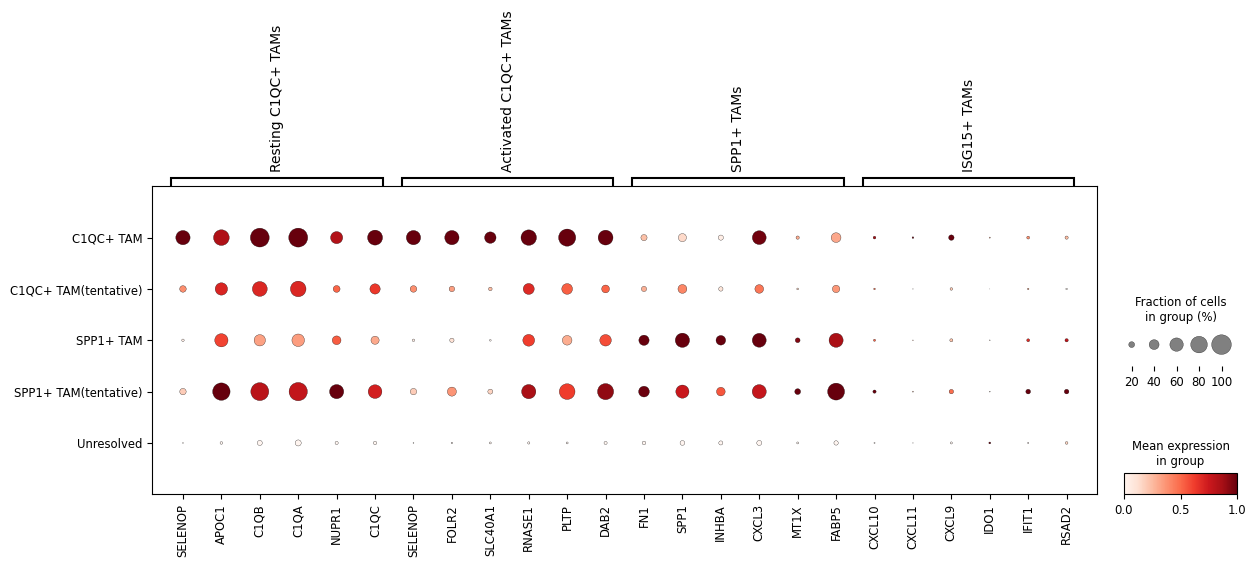

In [20]:
dotplot_markers = {
    "Resting C1QC+ TAMs": [
        "SELENOP", "APOC1", "C1QB", "C1QA", "NUPR1", "C1QC"
    ],
    "Activated C1QC+ TAMs": [
        "SELENOP", "FOLR2", "SLC40A1", "RNASE1", "PLTP", "DAB2"
    ],
    "SPP1+ TAMs": [
        "FN1", "SPP1", "INHBA", "CXCL3", "MT1X", "FABP5"
    ],
    "ISG15+ TAMs": [
        "CXCL10", "CXCL11", "CXCL9", "IDO1", "IFIT1", "RSAD2"
    ],
}

all_dotplot_genes = [
    gene
    for genes in dotplot_markers.values()
    for gene in genes
]

available_genes = [
    g for g in all_dotplot_genes
    if g in mac.var_names
]

missing_genes = [
    g for g in all_dotplot_genes
    if g not in mac.var_names
]

print("available:", available_genes)
print("missing:", missing_genes)

sc.pl.dotplot(
    mac,
    var_names=dotplot_markers,
    groupby="tam_subtype",
    use_raw=False,
    standard_scale="var",
    dendrogram=False,
    figsize=(14, 4),
    show=True
)

### dotplot 결과 해석

- **C1QC+ TAM core**  
    : SELENOP/APOC1/C1QB/C1QA/NUPR1/C1QC/FOLR2/SLC40A1/RNASE1/PLTP/DAB2 등 Resting/Activated C1QC-associated signature를 공유한다.  
- **C1QC+ TAM(tentative)**  
    : APOC1/C1QB/C1QA/RNASE1 정도만 C1QC-associated signature를 공유하였다.  
- **SPP1+ TAM core**
    : FN1/SPP1/INHBA/CXCL3/FABP5등이 SPP1-associated signature를 나타냈다.
- **SPP1+ TAM(tentative)**  
    : FN1/SPP1/INHBA/CXCL3/FABP5 등이 SPP1-associated signature를 나타내지만 core보다는 전체적으로 mean expression이 낮다.  
- 반면 ISG15-associated signature는 GSE127465 단일 폐암 데이터에서 뚜렷하게 관찰되지 않았다.  

이는 단일 암종 데이터의 한계로 해석되며, 이후 pan-cancer 데이터(GSE154763)에서 추가 검증하겠다.  

## 6. Biology interpretation note

### C1QC-associated TAM populations

GSE127465의 C1QC-associated macrophage population은 하나의 균일한 state가 아니라, 서로 다른 transcriptional tendency를 가진 두 population으로 관찰되었다.

C1QC+ TAM core에서는 `SELENOP`, `FOLR2`, `PLTP`, `SLC40A1`, `C1QA`, `C1QB` 등이 상위 DEG로 확인되었다. 이들 유전자는 reference paper의 Activated C1QC+ TAM signature에서도 높은 `avg_log2FC`를 보인 유전자이며, 본 데이터에서도 Activated C1QC+ TAM signature와 19/30개(63.3%)의 overlap을 보였다.

따라서 C1QC+ TAM core는 complement-associated macrophage feature와 함께 tissue-resident / lipid-handling macrophage program을 보이는 Activated C1QC-like TAM state로 해석하였다.

반면 C1QC+ TAM(tentative)은 Resting C1QC+ TAM signature와 13/24개(54.2%)의 overlap을 보였다. 상위 DEG에는 `FTL`, `CTSD`, `APOE`, `GPNMB`, `C1QA`, `C1QB`, `APOC1` 등이 포함되었으며, core C1QC+ TAM과 complement-related feature를 일부 공유하면서도 lysosomal / lipid-associated macrophage-related gene expression이 상대적으로 강하게 나타났다.

따라서 C1QC+ TAM(tentative)은 C1QC axis와 연관되지만 Activated C1QC+ TAM core와는 구분되는 Resting C1QC-like 또는 lysosome-enriched macrophage state로 해석하였다.

### SPP1+ TAM core

SPP1+ TAM core는 reference paper의 SPP1+ TAM signature와 가장 높은 overlap을 보였다. 논문 signature 9개 중 7개(77.8%)가 본 데이터의 top 50 DEG에 포함되었으며, `SPP1`, `FABP5`, `MARCO`, `FN1`, `CXCL3`, `INHBA`, `SDC2`가 확인되었다.

특히 `SPP1`은 해당 subtype에서 2위 DEG로 나타났다. 이는 본 population이 C1QC-associated population과 구별되는 SPP1-associated transcriptional program을 강하게 보유함을 지지한다.

Reference paper에서 SPP1+ TAM은 extracellular matrix remodeling, angiogenesis 및 inflammatory microenvironment와 연관된 macrophage state로 기술된다. 따라서 본 데이터에서도 SPP1+ TAM core는 이러한 기능적 방향성과 관련된 transcriptional state를 보이는 population으로 해석하였다.

### C1QC/SPP1 ambiguous tentative population

현재 `SPP1+ TAM(tentative)`로 분류된 population은 SPP1+ TAM signature보다 Resting C1QC+ TAM signature와 더 높은 overlap을 보였다.

Resting C1QC+ TAM signature와는 7/24개(29.2%)가 overlap되었으며, `TREM2`, `APOC1`, `CTSD`, `APOE`, `NUPR1`, `FTL`, `GPNMB`가 확인되었다. 반면 SPP1+ TAM signature와의 overlap은 `FABP5`, `MARCO` 두 개에 그쳤으며, `SPP1`, `FN1`, `INHBA`, `CXCL3` 등 core SPP1+ TAM에서 두드러진 핵심 유전자는 상위 DEG에서 확인되지 않았다.

해당 population은 marker score 기반 분석에서는 SPP1 axis가 C1QC axis보다 근소하게 높은 순위를 보였으나, subtype-vs-rest DEG composition 및 reference signature overlap은 Resting C1QC-like feature를 더 강하게 시사했다.

따라서 이 population은 현 시점에서 SPP1+ TAM으로 확정하기보다, C1QC/SPP1 axis 사이의 ambiguous macrophage population 또는 intermediate-like state로 해석하는 것이 적절하다. 최종 subtype assignment는 core C1QC+ TAM, C1QC+ TAM(tentative), SPP1+ TAM core와의 직접 DEG 비교를 통해 추가 검증하겠다. -> DEG-C ambiguous cluster 추가 검증  

### Unresolved population

Unresolved population은 reference paper의 Resting C1QC+, Activated C1QC+, SPP1+, ISG15+ TAM signature 모두와 top 50 DEG overlap을 보이지 않았다.

상위 DEG에는 `FCN1`, `CFP`, `SELL`, `CORO1A` 등이 포함되었으며, 이는 C1QC/SPP1 TAM axis보다는 monocyte-like myeloid feature와 더 가까운 transcriptional tendency를 시사한다.  

따라서 해당 population은 현재의 TAM marker framework로 안정적으로 분류하기 어려운 myeloid population으로 유지하였다.

### Interpretation

본 데이터의 macrophage population은 하나의 균질한 TAM 집단이 아니라, 서로 다른 transcriptional program을 가진 여러 macrophage state로 구성되어 있었다.

* C1QC+ TAM core는 Activated C1QC-like transcriptional program을 보였다.
* C1QC+ TAM(tentative)은 Resting C1QC-like 및 lysosomal/lipid-associated feature를 보였다.
* SPP1+ TAM core는 reference SPP1+ TAM signature를 강하게 재현하였다.
* 기존 SPP1+ TAM(tentative)은 SPP1-specific feature보다 Resting C1QC-associated feature를 더 많이 공유하여, C1QC/SPP1 ambiguous population으로 재검토가 필요하다.
* Unresolved population은 C1QC/SPP1 TAM framework 밖의 monocyte-like 또는 inflammatory myeloid state일 가능성을 보였다.

본 해석은 single-cell DEG, reference signature overlap 및 dotplot 기반의 transcriptional annotation이다. 따라서 phagocytosis, ECM remodeling, angiogenesis와 같은 기능은 직접 측정된 결과가 아니라 관련 transcriptional program을 통해 시사되는 기능적 방향성으로 해석하였다.


In [21]:
mac.write(MAC_PH2_H5AD)
print(f'저장 완료: {MAC_PH2_H5AD}')

저장 완료: dataset\GSE127465_mac_phase2a.h5ad


## 7. 추가 검증
### DEG-B. C1QC+ TAM core vs SPP1+ TAM core

두개의 core state가 직접 비교해도 분리가 되는지 검증한다.  
이때 tentative, ambiguous, Unresolved는 제외한다.  

In [22]:
CORE_C1QC = "C1QC+ TAM"
CORE_SPP1 = "SPP1+ TAM"

core_tam = mac[
    mac.obs["tam_subtype"].isin([
        CORE_C1QC,
        CORE_SPP1,
    ])
].copy()

print(core_tam.obs["tam_subtype"].value_counts())
print("core_tam shape:", core_tam.shape)

tam_subtype
C1QC+ TAM    1534
SPP1+ TAM     973
Name: count, dtype: int64
core_tam shape: (2507, 32634)


In [26]:
DEG_KEY_B_C1QC = "deg_c1qc_vs_spp1_core"

sc.tl.rank_genes_groups(
    core_tam,
    groupby="tam_subtype",
    groups=[CORE_C1QC],
    reference=CORE_SPP1,
    method="wilcoxon",
    corr_method="bonferroni",
    tie_correct=True,
    use_raw=False,
    pts=True,
    key_added=DEG_KEY_B_C1QC,
)

deg_b_c1qc = sc.get.rank_genes_groups_df(
    core_tam,
    group=CORE_C1QC,
    key=DEG_KEY_B_C1QC,
).copy()

print("===== C1QC+ TAM > SPP1+ TAM =====")
display(
    deg_b_c1qc[
        ["names", "logfoldchanges", "pvals_adj", "scores"]
    ].head(30)
)

===== C1QC+ TAM > SPP1+ TAM =====


c:\Users\82108\anaconda3\envs\spatial\lib\site-packages\scanpy\tools\_rank_genes_groups.py:347: RuntimeWarning: invalid value encountered in divide
  scores = (


,names,logfoldchanges,pvals_adj,scores
0,SELENOP,5.256143,7.541801e-179,28.877165
1,C1QA,2.947996,3.358207e-173,28.423746
2,C1QB,2.939869,4.590752e-161,27.424322
3,CD74,1.222519,2.653401e-151,26.593224
4,PLTP,3.095280,6.986971e-149,26.383112
5,FOLR2,3.673739,2.382975e-144,25.985081
6,HLA-DPB1,1.537485,2.039013e-126,24.346930
7,SLC40A1,4.664679,4.824800e-116,23.346996
8,FUCA1,2.827769,1.074891e-113,23.114708
9,EGR1,2.829362,1.632225e-113,23.096664


In [27]:
DEG_KEY_B_SPP1 = "deg_spp1_vs_c1qc_core"

sc.tl.rank_genes_groups(
    core_tam,
    groupby="tam_subtype",
    groups=[CORE_SPP1],
    reference=CORE_C1QC,
    method="wilcoxon",
    corr_method="bonferroni",
    tie_correct=True,
    use_raw=False,
    pts=True,
    key_added=DEG_KEY_B_SPP1,
)

deg_b_spp1 = sc.get.rank_genes_groups_df(
    core_tam,
    group=CORE_SPP1,
    key=DEG_KEY_B_SPP1,
).copy()

print("===== SPP1+ TAM > C1QC+ TAM =====")
display(
    deg_b_spp1[
        ["names", "logfoldchanges", "pvals_adj", "scores"]
    ].head(30)
)

===== SPP1+ TAM > C1QC+ TAM =====


c:\Users\82108\anaconda3\envs\spatial\lib\site-packages\scanpy\tools\_rank_genes_groups.py:347: RuntimeWarning: invalid value encountered in divide
  scores = (


,names,logfoldchanges,pvals_adj,scores
0,SH3BGRL3,1.559364,1.690993e-126,24.354603
1,FBP1,2.797249,1.791777e-116,23.389309
2,S100A10,1.763740,1.603860e-114,23.196712
3,S100A6,1.787016,2.655603e-98,21.530090
4,VIM,0.965690,1.132507e-96,21.355448
5,FLNA,2.019196,4.383167e-93,20.965916
6,SPP1,3.239462,3.694233e-90,20.642843
7,MCEMP1,3.863201,5.561064e-89,20.511375
8,S100A11,0.999937,1.297244e-86,20.244461
9,CD52,2.146645,8.669709e-84,19.921362


### result

1) C1QC+ TAM > SPP1+ TAM
: SELENOP, C1QA/B/C, PLTP, FOLR2, SLC40A1, SLCO2B1, F13A1, APOE, LGMN

> A에서 봤던 “Activated C1QC signature 19/30 overlap”이 direct comparison에서도 그대로 유지됨

2) SPP1+ TAM > C1QC+ TAM
: SPP1, MCEMP1, RETN, VCAN, FCN1, CLEC5A, S100A8, SLC11A1  

> 이 SPP1 core는 C1QC core와 확실히 다르긴 한데 정통 SPP1 TAM이라기보다 inflammatory-monocyte-like 성격을 동반한 SPP1-associated population임

B에서 reference marker가 실제로 다 살아있는지, 어느 정도 순위인지 확인해보겠다.  

In [28]:
spp1_reference_genes = [
    "SPP1", "FN1", "INHBA", "CXCL3", "MT1X",
    "FABP5", "SDC2", "CCL20", "MARCO",
]

spp1_check = deg_b_spp1[
    deg_b_spp1["names"].isin(spp1_reference_genes)
][
    ["names", "logfoldchanges", "pvals_adj", "scores"]
].copy()

display(spp1_check)

,names,logfoldchanges,pvals_adj,scores
6,SPP1,3.239462,3.694233e-90,20.642843
31,FABP5,1.605866,1.318416e-48,15.341461
44,INHBA,1.963701,1.864185e-34,13.058116
55,FN1,1.854186,3.178006e-30,12.294144
82,MARCO,1.063932,1.342795e-19,10.128847
162,SDC2,1.123875,7.104290e-10,7.639719
365,MT1X,1.043106,4.612110e-02,4.823122
807,CCL20,0.395521,1.000000e+00,3.016691
8705,CXCL3,0.046736,1.000000e+00,0.361263


In [30]:
c1qc_reference_genes = [
    "SELENOP", "FOLR2", "PLTP", "SLC40A1",
    "RNASE1", "DAB2", "C1QA", "C1QB",
    "C1QC", "SLCO2B1", "F13A1", "LGMN",
]

c1qc_check = deg_b_c1qc[
    deg_b_c1qc["names"].isin(c1qc_reference_genes)
][
    ["names", "logfoldchanges", "pvals_adj", "scores"]
].copy()

display(c1qc_check)

,names,logfoldchanges,pvals_adj,scores
0,SELENOP,5.256143,7.541801e-179,28.877165
1,C1QA,2.947996,3.358207e-173,28.423746
2,C1QB,2.939869,4.590752e-161,27.424322
4,PLTP,3.095280,6.986971e-149,26.383112
5,FOLR2,3.673739,2.382975e-144,25.985081
7,SLC40A1,4.664679,4.824800e-116,23.346996
16,SLCO2B1,1.620269,7.685475e-88,20.383247
18,F13A1,3.145311,3.175660e-86,20.200296
22,C1QC,2.247846,1.959337e-81,19.648081
25,LGMN,1.818493,2.025711e-74,18.810394


### DEG-B. Direct comparison of core C1QC+ and SPP1+ TAM states

Tentative 및 Unresolved population을 제외한 C1QC+ TAM core와 SPP1+ TAM core를 직접 비교하여, 두 core population의 transcriptional difference를 확인하였다.  

C1QC+ TAM core는 SPP1+ TAM core에 비해 `SELENOP`, `C1QA`, `C1QB`, `C1QC`, `PLTP`, `FOLR2`, `SLC40A1`, `SLCO2B1`, `F13A1`, `LGMN`, `DAB2`, `RNASE1` 등의 발현이 유의하게 높았다. 이는 Activated C1QC+ TAM signature에서 제시된 complement-associated, tissue-resident macrophage program이 direct comparison에서도 유지됨을 지지한다.  

반대로 SPP1+ TAM core는 C1QC+ TAM core에 비해 `SPP1`, `FABP5`, `INHBA`, `FN1`, `MARCO`, `SDC2`, `MT1X` 등의 발현이 유의하게 높았다. 특히 `SPP1`은 direct comparison에서도 높은 effect size를 보였으며, reference SPP1+ TAM signature의 다수 유전자가 같은 방향으로 확인되었다.  

또한 SPP1+ TAM core에서는 `RETN`, `VCAN`, `FCN1`, `CLEC5A`, `S100A8` 등이 상대적으로 높게 나타났다. 이는 해당 population이 C1QC+ TAM core와 구별되는 SPP1-associated transcriptional state를 가지면서, 일부 monocyte-like 또는 inflammatory myeloid-related feature를 함께 보일 가능성을 시사한다.  

반면 `CCL20`과 `CXCL3`는 subtype-vs-rest 분석에서는 SPP1+ TAM 관련 유전자로 확인되었으나, core C1QC+ TAM과의 direct comparison에서는 유의한 차이를 보이지 않았다. 따라서 이들 유전자는 SPP1+ TAM의 절대적 특이 marker라기보다, 비교 기준에 따라 차이가 달라질 수 있는 context-dependent feature로 해석하였다.  


## 8. 추가 검증
### DEG-C. Ambiguous population validation

핵심 비교:   
ambiguous vs SPP1+ TAM core  
ambiguous vs C1QC+ TAM(tentative)  
여기서 ambiguous는 지금의 SPP1+ TAM(tentative)를 말한다.  

In [31]:
AMBIGUOUS = "SPP1+ TAM(tentative)"
C1QC_TENTATIVE = "C1QC+ TAM(tentative)"
SPP1_CORE = "SPP1+ TAM"

c_groups = [
    AMBIGUOUS,
    C1QC_TENTATIVE,
    SPP1_CORE,
]

amb_tam = mac[
    mac.obs["tam_subtype"].isin(c_groups)
].copy()

print(amb_tam.obs["tam_subtype"].value_counts())
print("amb_tam shape:", amb_tam.shape)

tam_subtype
C1QC+ TAM(tentative)    1386
SPP1+ TAM                973
SPP1+ TAM(tentative)     943
Name: count, dtype: int64
amb_tam shape: (3302, 32634)


In [32]:
DEG_KEY_C_VS_SPP1 = "deg_ambiguous_vs_spp1_core"

sc.tl.rank_genes_groups(
    amb_tam,
    groupby="tam_subtype",
    groups=[AMBIGUOUS],
    reference=SPP1_CORE,
    method="wilcoxon",
    corr_method="bonferroni",
    tie_correct=True,
    use_raw=False,
    pts=True,
    key_added=DEG_KEY_C_VS_SPP1,
)

deg_c_vs_spp1 = sc.get.rank_genes_groups_df(
    amb_tam,
    group=AMBIGUOUS,
    key=DEG_KEY_C_VS_SPP1,
).copy()

display(
    deg_c_vs_spp1[
        ["names", "logfoldchanges", "pvals_adj", "scores"]
    ].head(30)
)

c:\Users\82108\anaconda3\envs\spatial\lib\site-packages\scanpy\tools\_rank_genes_groups.py:347: RuntimeWarning: invalid value encountered in divide
  scores = (


,names,logfoldchanges,pvals_adj,scores
0,C1QB,2.163818,1.583996e-69,18.203360
1,C1QA,2.010088,1.157499e-61,17.183216
2,FUCA1,1.803864,7.308823e-52,15.820707
3,APOE,1.788743,9.109071e-48,15.215488
4,CD59,1.470606,1.973111e-47,15.164823
5,CCL18,2.343390,6.909276e-46,14.929541
6,CTSZ,1.149615,6.633288e-45,14.777948
7,PLTP,1.617820,2.678484e-44,14.683630
8,STMN1,1.767839,1.918562e-42,14.391173
9,AKR1B1,1.405031,1.686596e-37,13.581326


In [33]:
DEG_KEY_SPP1_VS_C = "deg_spp1_core_vs_ambiguous"

sc.tl.rank_genes_groups(
    amb_tam,
    groupby="tam_subtype",
    groups=[SPP1_CORE],
    reference=AMBIGUOUS,
    method="wilcoxon",
    corr_method="bonferroni",
    tie_correct=True,
    use_raw=False,
    pts=True,
    key_added=DEG_KEY_SPP1_VS_C,
)

deg_spp1_vs_c = sc.get.rank_genes_groups_df(
    amb_tam,
    group=SPP1_CORE,
    key=DEG_KEY_SPP1_VS_C,
).copy()

display(
    deg_spp1_vs_c[
        ["names", "logfoldchanges", "pvals_adj", "scores"]
    ].head(30)
)

c:\Users\82108\anaconda3\envs\spatial\lib\site-packages\scanpy\tools\_rank_genes_groups.py:347: RuntimeWarning: invalid value encountered in divide
  scores = (


,names,logfoldchanges,pvals_adj,scores
0,TIMP1,1.653694,1.524319e-30,12.353375
1,PLAUR,0.614155,6.006393e-25,11.270247
2,BTG1,0.640272,2.600358e-20,10.288162
3,EREG,1.385520,5.166042e-19,9.996235
4,FCN1,1.850452,1.739916e-18,9.875219
5,SRGN,0.391747,8.815021e-18,9.711207
6,MALAT1,0.511899,4.867356e-17,9.535511
7,SOD2,0.595259,7.029626e-17,9.497297
8,MCL1,0.321424,8.420867e-13,8.464145
9,PPIF,0.778744,1.698890e-12,8.381948


In [36]:
DEG_KEY_C_VS_C1QC_TENT = "deg_ambiguous_vs_c1qc_tentative"

sc.tl.rank_genes_groups(
    amb_tam,
    groupby="tam_subtype",
    groups=[AMBIGUOUS],
    reference=C1QC_TENTATIVE,
    method="wilcoxon",
    corr_method="bonferroni",
    tie_correct=True,
    use_raw=False,
    pts=True,
    key_added=DEG_KEY_C_VS_C1QC_TENT,
)

deg_c_vs_c1qc_tent = sc.get.rank_genes_groups_df(
    amb_tam,
    group=AMBIGUOUS,
    key=DEG_KEY_C_VS_C1QC_TENT,
).copy()

display(
    deg_c_vs_c1qc_tent[
        ["names", "logfoldchanges", "pvals_adj", "scores"]
    ].head(30)
)

c:\Users\82108\anaconda3\envs\spatial\lib\site-packages\scanpy\tools\_rank_genes_groups.py:347: RuntimeWarning: invalid value encountered in divide
  scores = (


,names,logfoldchanges,pvals_adj,scores
0,RAN,2.066541,2.738075e-110,22.773533
1,ATP5G3,2.033599,7.121578e-106,22.323555
2,HNRNPM,1.993001,3.176466e-104,22.153122
3,PPIB,1.844945,2.739692e-101,21.846485
4,GSTO1,1.862369,6.708055e-101,21.805542
5,COX6A1,1.853510,1.457143e-100,21.770012
6,CYB5R3,1.981941,4.856654e-100,21.714758
7,CALU,1.893790,6.386812e-100,21.702169
8,LMAN2,1.827893,1.272809e-99,21.670439
9,VCP,1.810683,1.353850e-99,21.667595


In [37]:
DEG_KEY_C1QC_TENT_VS_C = "deg_c1qc_tentative_vs_ambiguous"

sc.tl.rank_genes_groups(
    amb_tam,
    groupby="tam_subtype",
    groups=[C1QC_TENTATIVE],
    reference=AMBIGUOUS,
    method="wilcoxon",
    corr_method="bonferroni",
    tie_correct=True,
    use_raw=False,
    pts=True,
    key_added=DEG_KEY_C1QC_TENT_VS_C,
)

deg_c1qc_tent_vs_c = sc.get.rank_genes_groups_df(
    amb_tam,
    group=C1QC_TENTATIVE,
    key=DEG_KEY_C1QC_TENT_VS_C,
).copy()

display(
    deg_c1qc_tent_vs_c[
        ["names", "logfoldchanges", "pvals_adj", "scores"]
    ].head(30)
)

c:\Users\82108\anaconda3\envs\spatial\lib\site-packages\scanpy\tools\_rank_genes_groups.py:347: RuntimeWarning: invalid value encountered in divide
  scores = (


,names,logfoldchanges,pvals_adj,scores
0,CD74,0.147714,7.310091e-09,7.333629
1,TPT1,0.050292,8.889019e-09,7.307388
2,SRGN,-0.191119,2.006905e-01,4.521175
3,HLA-DRB1,-0.054471,4.643294e-01,4.340307
4,HLA-DPA1,-0.227917,1.000000e+00,3.517484
5,HLA-DRA,-0.054661,1.000000e+00,3.178930
6,SELENOP,1.185471,1.000000e+00,2.744402
7,EEF1A1,-0.133125,1.000000e+00,2.283073
8,AL450311.2,23.419935,1.000000e+00,2.185159
9,FTH1,0.028580,1.000000e+00,2.148857


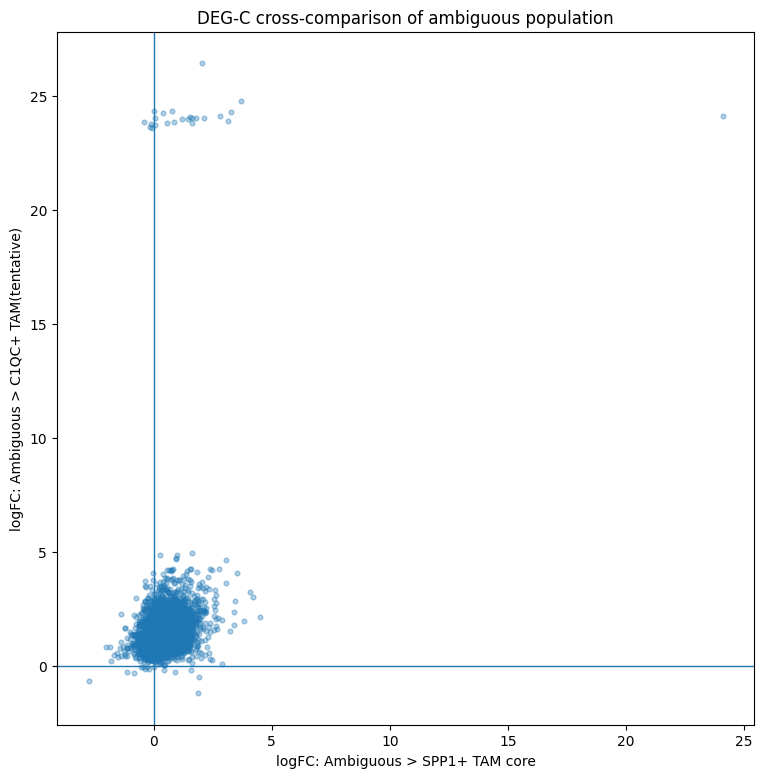

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 이미 만든 두 DEG table 사용
# deg_c_vs_spp1
# deg_c_vs_c1qc_tent

compare_df = (
    deg_c_vs_spp1[
        ["names", "logfoldchanges", "pvals_adj"]
    ]
    .rename(
        columns={
            "logfoldchanges": "lfc_amb_vs_spp1",
            "pvals_adj": "padj_amb_vs_spp1",
        }
    )
    .merge(
        deg_c_vs_c1qc_tent[
            ["names", "logfoldchanges", "pvals_adj"]
        ].rename(
            columns={
                "logfoldchanges": "lfc_amb_vs_c1qc_tent",
                "pvals_adj": "padj_amb_vs_c1qc_tent",
            }
        ),
        on="names",
        how="inner",
    )
)

# 양쪽 비교에서 적어도 하나는 유의한 유전자만
plot_df = compare_df[
    (compare_df["padj_amb_vs_spp1"] < 0.05)
    | (compare_df["padj_amb_vs_c1qc_tent"] < 0.05)
].copy()

plt.figure(figsize=(9, 9))

plt.scatter(
    plot_df["lfc_amb_vs_spp1"],
    plot_df["lfc_amb_vs_c1qc_tent"],
    alpha=0.35,
    s=12,
)

plt.axhline(0, linewidth=1)
plt.axvline(0, linewidth=1)

plt.xlabel("logFC: Ambiguous > SPP1+ TAM core")
plt.ylabel("logFC: Ambiguous > C1QC+ TAM(tentative)")
plt.title("DEG-C cross-comparison of ambiguous population")

plt.show()

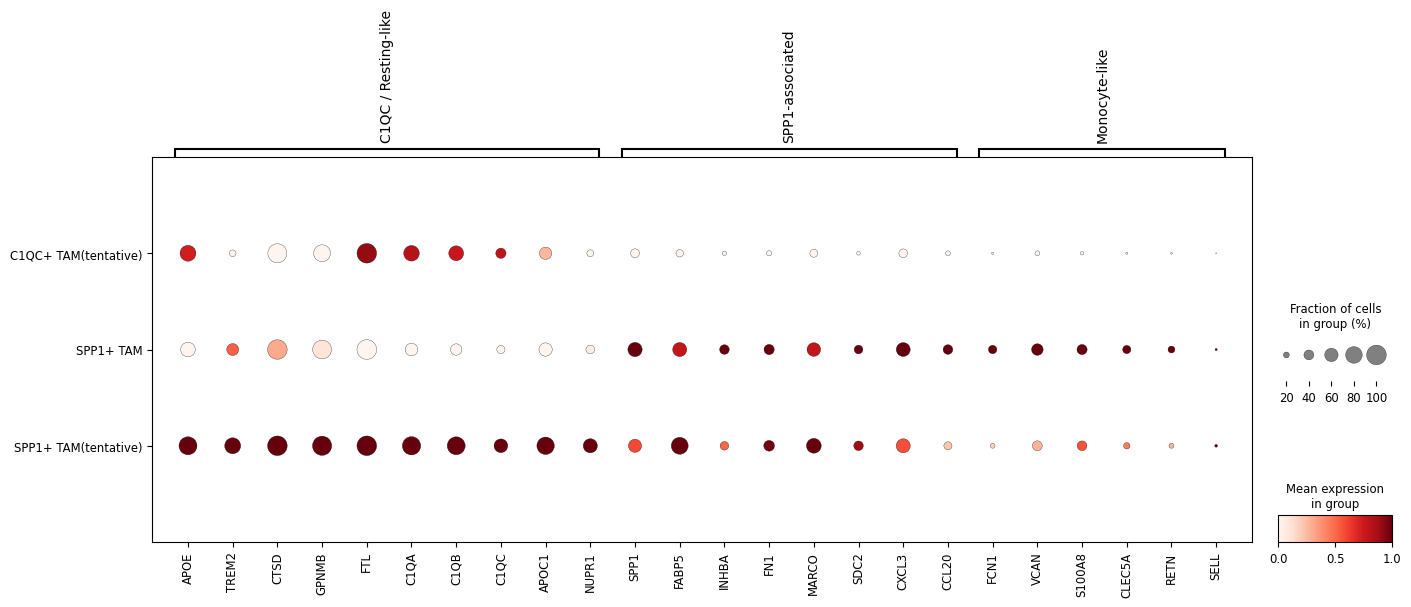

In [40]:
c_validation_markers = {
    "C1QC / Resting-like": [
        "APOE", "TREM2", "CTSD", "GPNMB",
        "FTL", "C1QA", "C1QB", "C1QC",
        "APOC1", "NUPR1",
    ],
    "SPP1-associated": [
        "SPP1", "FABP5", "INHBA", "FN1",
        "MARCO", "SDC2", "CXCL3", "CCL20",
    ],
    "Monocyte-like": [
        "FCN1", "VCAN", "S100A8",
        "CLEC5A", "RETN", "SELL",
    ],
}

available_markers = {
    group: [g for g in genes if g in amb_tam.var_names]
    for group, genes in c_validation_markers.items()
}

sc.pl.dotplot(
    amb_tam,
    var_names=available_markers,
    groupby="tam_subtype",
    use_raw=False,
    standard_scale="var",
    dendrogram=False,
    figsize=(16, 5),
)

In [39]:
c1qc_like_genes = [
    "APOE", "TREM2", "CTSD", "GPNMB",
    "FTL", "C1QA", "C1QB", "C1QC",
]

spp1_like_genes = [
    "SPP1", "FABP5", "INHBA", "FN1",
    "MARCO", "SDC2", "CXCL3", "CCL20",
]

def show_signature_hits(df, genes, title):
    print(f"\n===== {title} =====")
    display(
        df[df["names"].isin(genes)][
            ["names", "logfoldchanges", "pvals_adj", "scores"]
        ]
    )

show_signature_hits(
    deg_c_vs_spp1,
    c1qc_like_genes,
    "Ambiguous > SPP1 core : C1QC-like genes",
)

show_signature_hits(
    deg_spp1_vs_c,
    spp1_like_genes,
    "SPP1 core > Ambiguous : SPP1-like genes",
)

show_signature_hits(
    deg_c_vs_c1qc_tent,
    spp1_like_genes,
    "Ambiguous > C1QC tentative : SPP1-like genes",
)

show_signature_hits(
    deg_c1qc_tent_vs_c,
    c1qc_like_genes,
    "C1QC tentative > Ambiguous : C1QC-like genes",
)


===== Ambiguous > SPP1 core : C1QC-like genes =====


,names,logfoldchanges,pvals_adj,scores
0,C1QB,2.163818,1.583996e-69,18.203360
1,C1QA,2.010088,1.157499e-61,17.183216
3,APOE,1.788743,9.109071e-48,15.215488
14,C1QC,1.479267,1.718903e-31,12.527694
92,FTL,0.456980,5.338903e-16,9.283761
643,TREM2,0.649285,4.203773e-07,6.769962
651,CTSD,0.308745,4.870370e-07,6.748635
1393,GPNMB,0.415245,2.143141e-04,5.801633



===== SPP1 core > Ambiguous : SPP1-like genes =====


,names,logfoldchanges,pvals_adj,scores
30,CCL20,1.117101,0.000200,5.812960
47,SPP1,0.793306,0.125827,4.619013
62,CXCL3,0.493612,1.000000,4.159739
70,INHBA,0.743209,1.000000,3.877904
9699,SDC2,0.128487,1.000000,-0.385212
9708,FN1,0.021235,1.000000,-0.395219
25261,MARCO,-0.292380,1.000000,-2.968637
26277,FABP5,-0.341894,1.000000,-3.302292



===== Ambiguous > C1QC tentative : SPP1-like genes =====


,names,logfoldchanges,pvals_adj,scores
432,FABP5,1.764310,6.847356e-71,18.374607
2380,MARCO,1.491681,1.892192e-41,14.232020
2484,SDC2,1.350381,1.954482e-40,14.067816
2959,FN1,1.663410,2.967311e-36,13.369683
5477,INHBA,1.068557,4.955745e-20,10.225870
5981,SPP1,1.260274,4.895442e-18,9.770969
7432,CXCL3,0.746030,3.027486e-12,8.313690
8733,CCL20,0.430670,3.442308e-08,7.123158



===== C1QC tentative > Ambiguous : C1QC-like genes =====


,names,logfoldchanges,pvals_adj,scores
1197,C1QA,-0.342490,1.000000e+00,0.093777
4366,FTL,-0.041892,1.000000e+00,-0.157592
10652,GPNMB,-0.461690,1.000000e+00,-1.492537
13625,C1QB,-0.468984,1.000000e+00,-2.056227
15021,APOE,-0.465730,1.000000e+00,-2.207208
17138,C1QC,-0.264408,1.000000e+00,-2.883380
22679,CTSD,-0.445443,3.590399e-05,-6.094151
31923,TREM2,-1.547394,3.441933e-64,-17.517437


### DEG-C. Validation of the C1QC/SPP1 ambiguous population

기존에 `SPP1+ TAM(tentative)`로 분류된 population은 reference signature overlap 분석에서 Resting C1QC+ TAM signature와 더 많은 overlap을 보였으나, marker score 기반 annotation에서는 SPP1 axis가 상대적으로 높게 나타나 최종 subtype assignment가 불확실하였다. 이에 해당 population이 C1QC+ TAM(tentative) 또는 SPP1+ TAM core 중 어느 population과 더 유사한지 확인하기 위해 direct DEG comparison을 수행하였다.

먼저 ambiguous population과 SPP1+ TAM core를 비교한 결과, ambiguous population에서는 `C1QB`, `C1QA`, `C1QC`, `APOE`, `FTL`, `TREM2`, `CTSD`, `GPNMB` 등의 발현이 유의하게 높았다. 이는 해당 population이 SPP1+ TAM core에 비해 complement-associated 및 lipid/lysosomal macrophage-related feature를 더 강하게 보유함을 시사한다.

반대로 ambiguous population과 C1QC+ TAM(tentative)을 비교한 결과, ambiguous population에서는 `FABP5`, `MARCO`, `SDC2`, `FN1`, `INHBA`, `SPP1`, `CXCL3`, `CCL20` 등 SPP1-associated signature gene이 유의하게 높았다. 특히 `SPP1`, `FABP5`, `MARCO`, `FN1`, `INHBA`, `SDC2`가 모두 C1QC+ TAM(tentative)보다 높은 방향으로 확인되어, 해당 population이 Resting C1QC-like tentative population과도 구별되는 SPP1-associated feature를 가짐을 확인하였다.

한편 SPP1+ TAM core가 ambiguous population보다 높은 방향에서는 `CCL20`이 유의하게 확인되었으나, `SPP1`, `CXCL3`, `INHBA`, `FN1`, `MARCO`, `FABP5` 등 일부 SPP1 signature gene은 Bonferroni 보정 이후 유의한 차이를 보이지 않았다. 따라서 ambiguous population은 SPP1+ TAM core와 완전히 동일한 transcriptional state라기보다, SPP1 core보다 상대적으로 강한 C1QC/lipid-lysosomal macrophage feature를 함께 보이는 population으로 해석하였다.

종합하면, 해당 population은 SPP1+ TAM core에 비해서는 C1QC-associated feature가 높고, C1QC+ TAM(tentative)에 비해서는 SPP1-associated feature가 높았다. 따라서 해당 cluster는 C1QC+ TAM(tentative) 또는 SPP1+ TAM core 중 하나로 단순히 재분류하기보다는, 두 transcriptional axis를 함께 보이는 `C1QC/SPP1 mixed-signature TAM` 또는 `C1QC/SPP1 ambiguous TAM`으로 유지하는 것이 적절하다.

본 분석은 DEG 기반 transcriptional comparison에 근거한 annotation이며, 해당 population이 실제 분화 과정의 intermediate 또는 transitional state임을 직접 입증한 것은 아니다. 따라서 “intermediate”보다는 “mixed-signature” 또는 “ambiguous”라는 표현을 사용하였다.


## 9. 검증 결과
### Final re-annotation

초기 subtype annotation은 marker score 및 reference signature 기반으로 수행하였다. 이후 DEG-A, DEG-B 및 DEG-C를 통해 각 population의 transcriptional feature를 추가 검증하였다.

그 결과 기존 `SPP1+ TAM(tentative)` population은 SPP1+ TAM core에 비해서는 C1QC-associated lipid/lysosomal feature를 높게 보였고, C1QC+ TAM(tentative)에 비해서는 SPP1-associated signature gene을 높게 보였다.

따라서 해당 population은 어느 한 subtype으로 단순 재배정하기보다, 두 transcriptional axis를 함께 보이는 `C1QC/SPP1 mixed-signature TAM`으로 최종 재어노테이션하였다.


=== Initial annotation ===
tam_subtype_initial
Unresolved              4731
C1QC+ TAM               1534
C1QC+ TAM(tentative)    1386
SPP1+ TAM                973
SPP1+ TAM(tentative)     943
Name: count, dtype: int64

=== Final annotation ===
tam_subtype_final
Unresolved                       4731
C1QC+ TAM                        1534
C1QC+ TAM(tentative)             1386
SPP1+ TAM                         973
C1QC/SPP1 mixed-signature TAM     943
Name: count, dtype: int64
tam_subtype_final
Unresolved                       49.45
C1QC+ TAM                        16.03
C1QC+ TAM(tentative)             14.49
SPP1+ TAM                        10.17
C1QC/SPP1 mixed-signature TAM     9.86
Name: proportion, dtype: float64


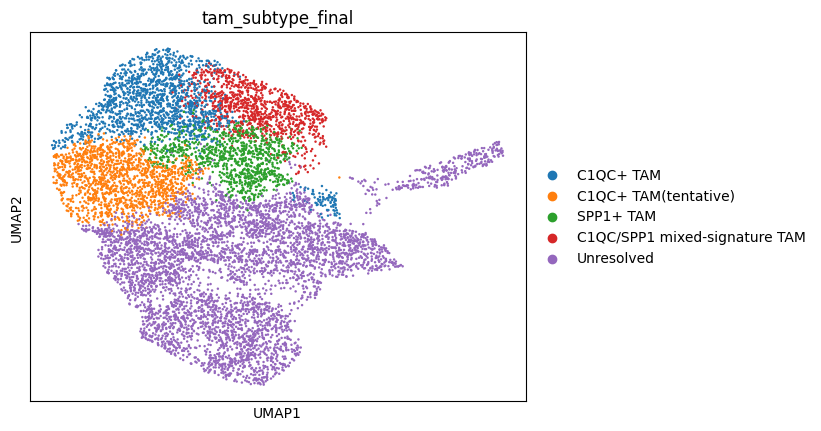

In [42]:
# 초기 annotation 보존
mac.obs["tam_subtype_initial"] = mac.obs["tam_subtype"].copy()

# 기존 annotation을 복사하여 백업하고 검증된 cluster만 최종 라벨로 변경
mac.obs["tam_subtype_final"] = (
    mac.obs["tam_subtype"]
    .astype(str)
    .replace({
        "SPP1+ TAM(tentative)": "C1QC/SPP1 mixed-signature TAM"
    })
)

final_order = [
    "C1QC+ TAM",
    "C1QC+ TAM(tentative)",
    "SPP1+ TAM",
    "C1QC/SPP1 mixed-signature TAM",
    "Unresolved",
]

mac.obs["tam_subtype_final"] = pd.Categorical(
    mac.obs["tam_subtype_final"],
    categories=final_order,
    ordered=True,
)

print("=== Initial annotation ===")
print(mac.obs["tam_subtype_initial"].value_counts())

print("\n=== Final annotation ===")
print(mac.obs["tam_subtype_final"].value_counts())
print((mac.obs["tam_subtype_final"].value_counts(normalize=True) * 100).round(2))

sc.pl.umap(
    mac,
    color="tam_subtype_final",
    # legend_loc="on data",
)

## 10. 중간 결과 저장

다음 notebook(`03_TME_composition.ipynb`)에서 TME composition 분석을 수행하기 위해, DEG 기반 최종 재어노테이션 결과(tam_subtype_final)가 포함된 macrophage subset을 저장한다.

In [44]:
mac.write_h5ad(MAC_SUB_H5AD)
print(f'저장 완료: {MAC_SUB_H5AD}')

저장 완료: dataset\GSE127465_mac_subtyped.h5ad
